In [1]:
%cd ..

/home/matt/Programming/repos/sc-demand-forecasting


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.blob_io import download_from_blob

In [3]:
DATA_DIR = Path("data").resolve()
assert DATA_DIR.exists()

CALENDAR_PATH = DATA_DIR / "calendar.csv"
PRICES_PATH = DATA_DIR / "sell_prices.csv"
SALES_PATH = DATA_DIR / "sales_train_evaluation.csv"

input_paths = [CALENDAR_PATH, PRICES_PATH, SALES_PATH]
missing_files = [path for path in input_paths if not path.exists()]
if missing_files:
    print(f"Missing {len(missing_files)} files. Downloading...\n")
    for path in missing_files:
        download_from_blob("raw", path.name, output_path=path)
else:
    print("No missing files.")

print(f"All {len(input_paths)} files are present:\n")
for path in input_paths:
    print(f"  '{path.name}'")

No missing files.
All 3 files are present:

  'calendar.csv'
  'sell_prices.csv'
  'sales_train_evaluation.csv'


## Helpers

In [4]:
def summarize_data(df: pd.DataFrame, index: bool=False) -> pd.DataFrame:
    """
    Returns a summary of data types, nulls, memory usage, and example values.
    """
    summary = pd.DataFrame({
        "# Null":  df.isna().sum(),
        "% Null":  df.isna().mean(),
        "Memory Usage":  df.memory_usage(index=index),
    })
    
    # Add "# Values" and sum (Total = Total values in DataFrame)
    summary.insert(1, "# Values", len(df))  # After "# Null"
    summary.loc["Total"] = summary.sum(axis=0, numeric_only=True)

    summary.insert(0, "DType", df.dtypes)
    summary = pd.concat([summary, df.head(3).transpose()], axis=1)
    
    # Remaining values are strings -- fill with blank
    summary = summary.fillna("")

    # Format numbers
    format_integer = "{:,.0f}".format
    format_percent = "{:,.2%}".format
    def format_bytes(size: int) -> str:
        unit_index = int(np.log(size) // np.log(1024))
        units = ["B", "KB", "MB", "GB"][unit_index]
        size_in_units = size / (1024 ** unit_index)
        if size_in_units >= 100:
            return f"{size_in_units:,.0f} {units}"
        if size_in_units >= 10:
            return f"{size_in_units:.1f} {units}"
        else:
            return f"{size_in_units:.2f} {units}"
        
    summary["# Null"] = summary["# Null"].map(format_integer)
    summary["# Values"] = summary["# Values"].map(format_integer)
    summary["% Null"] = summary["% Null"].map(format_percent)
    summary["Memory Usage"] = summary["Memory Usage"].map(format_bytes)

    summary = (
        summary
        .rename_axis("Column", axis=0)
        .reset_index()
        .set_index([
            "Column", "DType", "# Null", "# Values", "% Null", "Memory Usage"
        ])
        .rename_axis("Values", axis=1)
    )

    return summary

## Load Data

### Calendar

In [5]:
summarize_data(pd.read_csv(CALENDAR_PATH))

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
date,object,0,"1,969",0.00%,15.4 KB,2011-01-29,2011-01-30,2011-01-31
wm_yr_wk,int64,0,"1,969",0.00%,15.4 KB,11101,11101,11101
weekday,object,0,"1,969",0.00%,15.4 KB,Saturday,Sunday,Monday
wday,int64,0,"1,969",0.00%,15.4 KB,1,2,3
month,int64,0,"1,969",0.00%,15.4 KB,1,1,1
year,int64,0,"1,969",0.00%,15.4 KB,2011,2011,2011
d,object,0,"1,969",0.00%,15.4 KB,d_1,d_2,d_3
event_name_1,object,"1,807","1,969",91.77%,15.4 KB,,,
event_type_1,object,"1,807","1,969",91.77%,15.4 KB,,,


Not a lot to do on this one -- just need to parse the dates. Also, to save some
space, I'm going to convert `d` to type category -- this will save a ton of
space when we join on the Sales data.

In [6]:
calendar = pd.read_csv(CALENDAR_PATH, parse_dates=["date"])
calendar = calendar.astype({"d": "category", "weekday": "category"})
summarize_data(calendar)

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
date,datetime64[ns],0,"1,969",0.00%,15.4 KB,2011-01-29 00:00:00,2011-01-30 00:00:00,2011-01-31 00:00:00
wm_yr_wk,int64,0,"1,969",0.00%,15.4 KB,11101,11101,11101
weekday,category,0,"1,969",0.00%,2.27 KB,Saturday,Sunday,Monday
wday,int64,0,"1,969",0.00%,15.4 KB,1,2,3
month,int64,0,"1,969",0.00%,15.4 KB,1,1,1
year,int64,0,"1,969",0.00%,15.4 KB,2011,2011,2011
d,category,0,"1,969",0.00%,83.8 KB,d_1,d_2,d_3
event_name_1,object,"1,807","1,969",91.77%,15.4 KB,,,
event_type_1,object,"1,807","1,969",91.77%,15.4 KB,,,


No major issues -- can keep as-is.

### Prices

In [7]:
summarize_data(pd.read_csv(PRICES_PATH))

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
store_id,object,0,"6,841,121",0.00%,52.2 MB,CA_1,CA_1,CA_1
item_id,object,0,"6,841,121",0.00%,52.2 MB,HOBBIES_1_001,HOBBIES_1_001,HOBBIES_1_001
wm_yr_wk,int64,0,"6,841,121",0.00%,52.2 MB,11325,11326,11327
sell_price,float64,0,"6,841,121",0.00%,52.2 MB,9.58,9.58,8.26
Total,,0,"27,364,484",0.00%,209 MB,,,


From the [data dictionary](../docs/data-dictionary.md), we know that the prices
data doesn't have data for ever week. Will need to fill in missing values at
some point, but for EDA we can skip this -- only look at prices when the
products were sold. For now, can do a **forward fill** first, then a **backfill**
for anything remaining.

Right now, the data isn't showing any null values -- the rows simply aren't
present when there are no sales. To fix this and apply the forward-fill:

1. Pivot the store/item to the index and the week to the columns.
2. Apply the forward fill + backfill along `axis=1`.
3. Unpivot (melt) back to long-form.

In [8]:
prices = pd.read_csv(PRICES_PATH)

# Pivot then un-pivot to get the full range of values
prices = (
    prices
    .pivot(
        index=["store_id", "item_id"],
        columns="wm_yr_wk",
        values="sell_price",
    )
    .ffill(axis=1)
    .bfill(axis=1)
    .reset_index()
    .melt(
        id_vars=["store_id", "item_id"],
        value_vars=None, # Infer - remaining columns
        var_name="wm_yr_wk",
        value_name="sell_price",
    )
    .astype({
        "store_id": "category",
        "item_id": "category",
        "wm_yr_wk": int,
        "sell_price": float,
    })
)

summarize_data(prices)

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
store_id,category,0,"8,598,180",0.00%,8.20 MB,CA_1,CA_1,CA_1
item_id,category,0,"8,598,180",0.00%,16.5 MB,FOODS_1_001,FOODS_1_002,FOODS_1_003
wm_yr_wk,int64,0,"8,598,180",0.00%,65.6 MB,11101,11101,11101
sell_price,float64,0,"8,598,180",0.00%,65.6 MB,2.0,7.88,2.88
Total,,0,"34,392,720",0.00%,156 MB,,,


### Sales

In [9]:
summarize_data(pd.read_csv(SALES_PATH))

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
id,object,0,"30,490",0.00%,238 KB,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_003_CA_1_evaluation
item_id,object,0,"30,490",0.00%,238 KB,HOBBIES_1_001,HOBBIES_1_002,HOBBIES_1_003
dept_id,object,0,"30,490",0.00%,238 KB,HOBBIES_1,HOBBIES_1,HOBBIES_1
cat_id,object,0,"30,490",0.00%,238 KB,HOBBIES,HOBBIES,HOBBIES
store_id,object,0,"30,490",0.00%,238 KB,CA_1,CA_1,CA_1
...,...,...,...,...,...,...,...,...
d_1938,int64,0,"30,490",0.00%,238 KB,3,0,2
d_1939,int64,0,"30,490",0.00%,238 KB,3,0,3
d_1940,int64,0,"30,490",0.00%,238 KB,0,0,0


Sales comes with a few identifying columns, but the `d_1` through `d_1941` will
have to be un-pivoted. These are sales units columns. 

Also, the `id` column isn't really needed -- it doesn't add any additional
information.

In [10]:
sales = pd.read_csv(SALES_PATH)

sales = (
    sales
    .drop(columns=["id", "dept_id", "cat_id", "state_id"])
    .melt(
        id_vars=["item_id", "store_id"],
        value_vars=None, # Infer remaining
        var_name="d",
        value_name="sales_units",
    )
    .astype({col: "category" for col in ["item_id", "store_id", "d"]})
)

summarize_data(sales)

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
item_id,category,0,"59,181,090",0.00%,113 MB,HOBBIES_1_001,HOBBIES_1_002,HOBBIES_1_003
store_id,category,0,"59,181,090",0.00%,56.4 MB,CA_1,CA_1,CA_1
d,category,0,"59,181,090",0.00%,113 MB,d_1,d_1,d_1
sales_units,int64,0,"59,181,090",0.00%,452 MB,0,0,0
Total,,0,"236,724,360",0.00%,734 MB,,,


This is a very large DataFrame -- 734 MB. Note that this is down from 3.53 GB
when we kept the strings as `str` dtype instead of `category`.

### Merge Data

In [11]:
df = (
    sales
    .merge(
        calendar[["d", "date", "wm_yr_wk"]],
        how="left",
        on="d",
        validate="m:1",
    )
    .drop(columns="d")
    .merge(
        prices,
        how="left",
        on=["store_id", "item_id", "wm_yr_wk"],
        validate="m:1",
    )
    .drop(columns="wm_yr_wk")
)

display(summarize_data(df))
df.head()

,,,,,Values,0,1,2
Column,DType,# Null,# Values,% Null,Memory Usage,,,
item_id,category,0,"59,181,090",0.00%,113 MB,HOBBIES_1_001,HOBBIES_1_002,HOBBIES_1_003
store_id,category,0,"59,181,090",0.00%,56.4 MB,CA_1,CA_1,CA_1
sales_units,int64,0,"59,181,090",0.00%,452 MB,0,0,0
date,datetime64[ns],0,"59,181,090",0.00%,452 MB,2011-01-29 00:00:00,2011-01-29 00:00:00,2011-01-29 00:00:00
sell_price,float64,0,"59,181,090",0.00%,452 MB,9.58,3.97,2.97
Total,,0,"295,905,450",0.00%,1.49 GB,,,


,item_id,store_id,sales_units,date,sell_price
0,HOBBIES_1_001,CA_1,0,2011-01-29,9.58
1,HOBBIES_1_002,CA_1,0,2011-01-29,3.97
2,HOBBIES_1_003,CA_1,0,2011-01-29,2.97
3,HOBBIES_1_004,CA_1,0,2011-01-29,4.34
4,HOBBIES_1_005,CA_1,0,2011-01-29,2.98


## Exploration

In [12]:
df = df.assign(
    dept_id=df["item_id"].str.rsplit("_", n=1).str[0].astype("category"),
    cat_id=df["item_id"].str.split("_").str[0].astype("category"),
    state_id=df["store_id"].str.split("_").str[0].astype("category"),
    sales_amount=df["sales_units"].mul(df["sell_price"]),
)

### Prices

/tmp/ipykernel_3912/3976369505.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


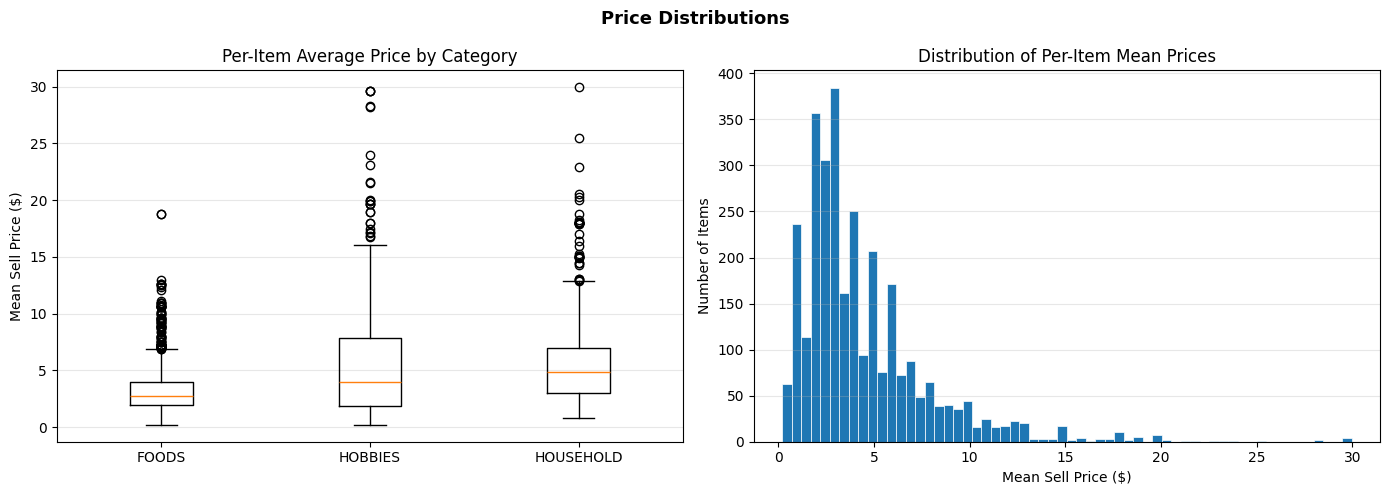

In [13]:
item_prices = (
    df.groupby(["item_id", "cat_id"], observed=True)["sell_price"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cats = item_prices["cat_id"].cat.categories
axes[0].boxplot(
    [item_prices.loc[item_prices["cat_id"] == c, "sell_price"].values for c in cats],
    labels=cats,
)
axes[0].set_title("Per-Item Average Price by Category")
axes[0].set_ylabel("Mean Sell Price ($)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(item_prices["sell_price"], bins=60, edgecolor="white", linewidth=0.5)
axes[1].set_title("Distribution of Per-Item Mean Prices")
axes[1].set_xlabel("Mean Sell Price ($)")
axes[1].set_ylabel("Number of Items")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Price Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

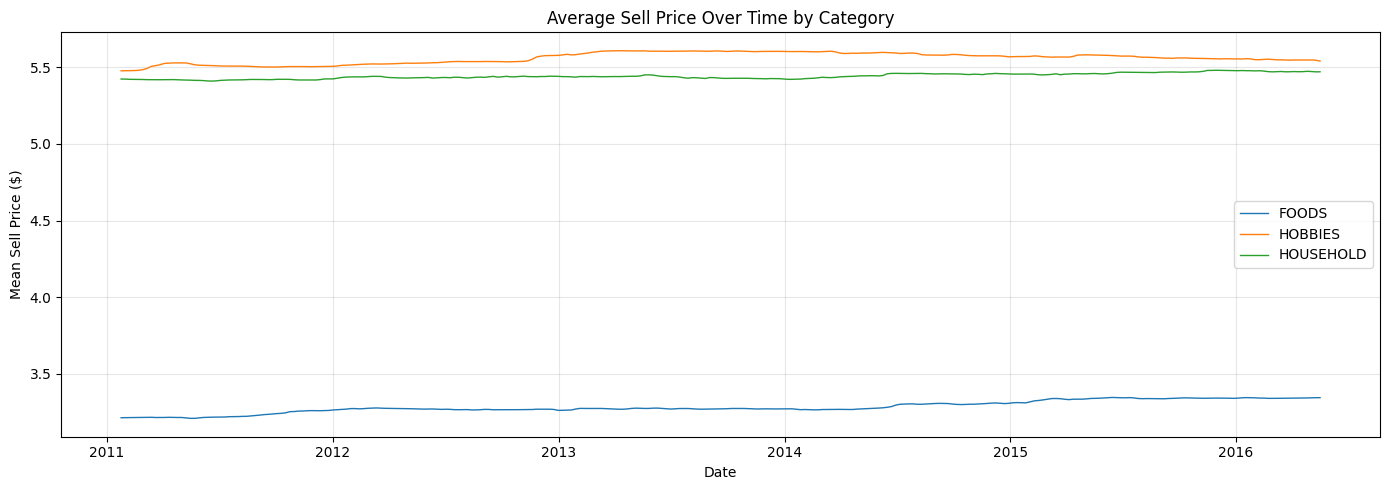

In [14]:
weekly_prices = (
    df.assign(week=df["date"].dt.to_period("W"))
    .groupby(["week", "cat_id"], observed=True)["sell_price"]
    .mean()
    .reset_index()
)
weekly_prices["week_dt"] = weekly_prices["week"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
for cat in weekly_prices["cat_id"].cat.categories:
    sub = weekly_prices[weekly_prices["cat_id"] == cat]
    ax.plot(sub["week_dt"], sub["sell_price"], label=cat, linewidth=1)
ax.set_title("Average Sell Price Over Time by Category")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Sell Price ($)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Business implication:** Prices vary substantially across categories — FOODS items skew cheaper while HOBBIES items show a long right tail of expensive SKUs. The mean sell price is also not static: the chart above shows gradual inflation trends over time. This price variation is structurally important for demand forecasting — we should include price features (level, week-over-week change, relative position within category) rather than treating price as constant.

### Sales Volume

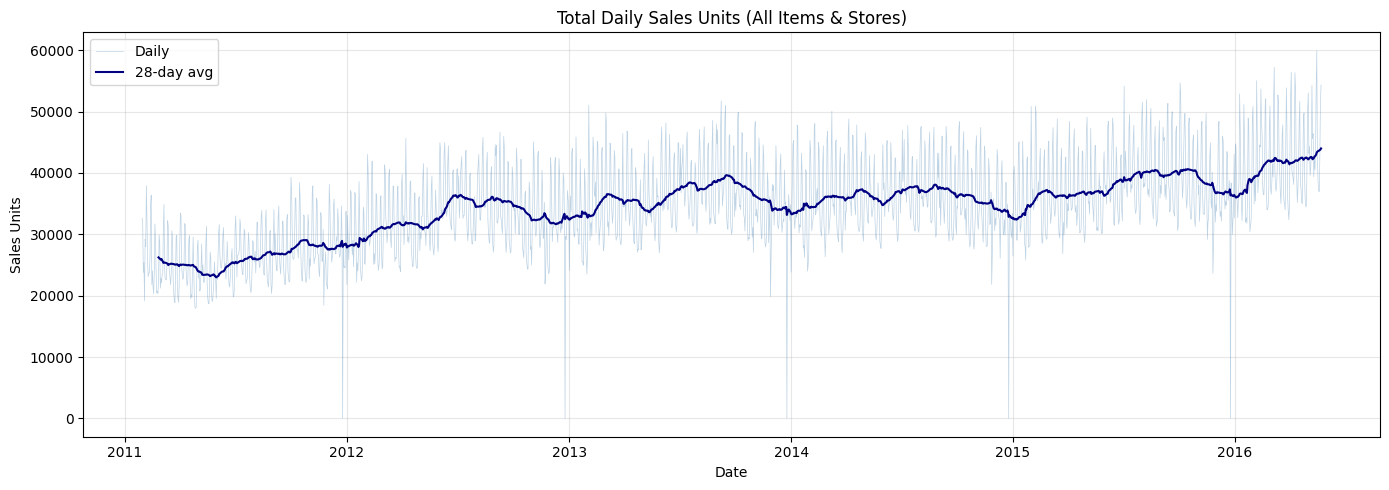

In [15]:
daily_sales = df.groupby("date")["sales_units"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_sales["date"], daily_sales["sales_units"],
        alpha=0.35, linewidth=0.5, color="steelblue", label="Daily")
rolling = daily_sales.set_index("date")["sales_units"].rolling(28).mean()
ax.plot(rolling.index, rolling.values, color="navy", linewidth=1.5, label="28-day avg")
ax.set_title("Total Daily Sales Units (All Items & Stores)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales Units")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3912/3307196025.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_product = df.groupby("item_id")["sales_units"].mean().map(np.log1p)


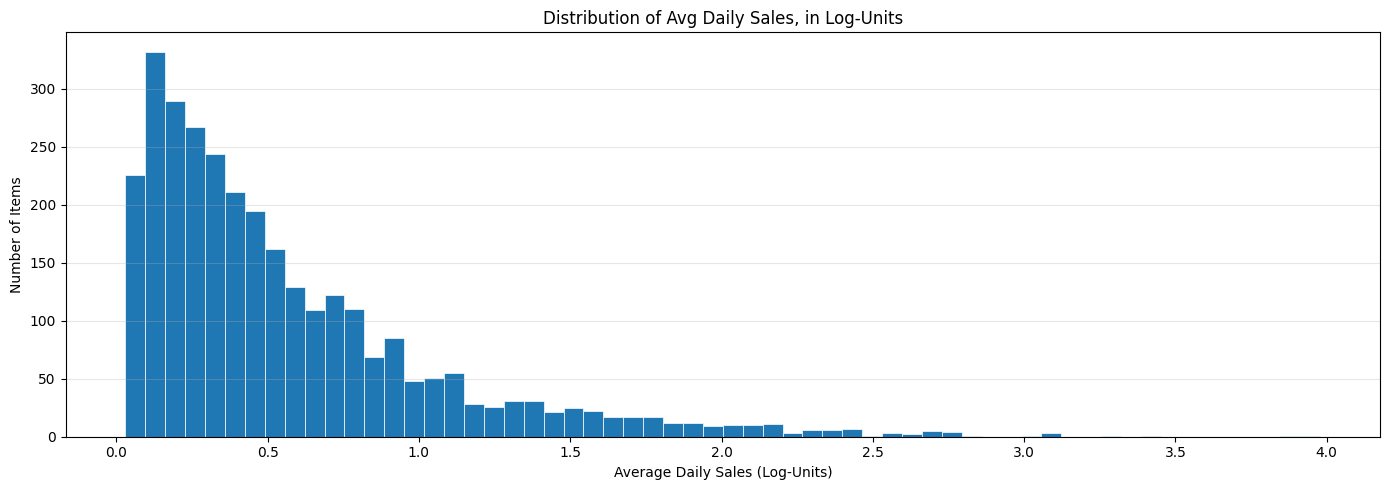

In [16]:
sales_by_product = df.groupby("item_id")["sales_units"].mean().map(np.log1p)

fig, ax = plt.subplots(figsize=(14, 5))

ax.hist(sales_by_product, bins=60, edgecolor="white", linewidth=0.5)
ax.set_title("Distribution of Avg Daily Sales, in Log-Units")
ax.set_xlabel("Average Daily Sales (Log-Units)")
ax.set_ylabel("Number of Items")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Business implication:** The log-scale distribution above reveals extreme skewness: a small handful of items account for the vast majority of sales volume. This is the classic long-tail structure seen in retail — and it is the empirical foundation for **ABC classification**. Inventory policy that treats all SKUs equally wastes capital on slow-movers while under-serving high-volume items.

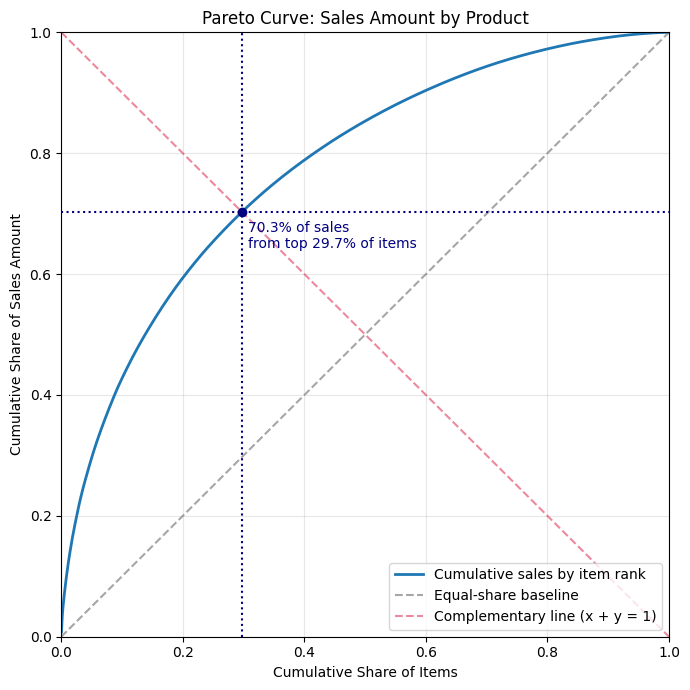

In [17]:
# Pareto by Product
sales_pareto = (
    df
    .groupby("item_id", observed=True)   # observed=True: exclude unused category levels
    ["sales_amount"].sum()
    .sort_values(ascending=False)
    .div(df["sales_amount"].sum())
    .cumsum()
    .to_frame("percent_of_sales")
)
sales_pareto["percent_of_items"] = (
    np.arange(1, len(sales_pareto) + 1) / len(sales_pareto)
)

x = sales_pareto["percent_of_items"].to_numpy()
y = sales_pareto["percent_of_sales"].to_numpy()

# Find where y% of sales is explained by (1-y)% of items, i.e. x + y = 1
idx = np.argmin(np.abs(x + y - 1.0))
x_cross, y_cross = x[idx], y[idx]

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x, y, linewidth=2, label="Cumulative sales by item rank")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.7, label="Equal-share baseline")
ax.plot([0, 1], [1, 0], linestyle="--", color="crimson", alpha=0.5, linewidth=1.5, label="Complementary line (x + y = 1)")

ax.axhline(y_cross, color="navy", linestyle=":", linewidth=1.5)
ax.axvline(x_cross, color="navy", linestyle=":", linewidth=1.5)
ax.scatter([x_cross], [y_cross], color="navy", zorder=3)
ax.text(
    x_cross + 0.01, y_cross - 0.06,
    f"{y_cross:.1%} of sales\nfrom top {x_cross:.1%} of items",
    color="navy"
)

ax.set_title("Pareto Curve: Sales Amount by Product")
ax.set_xlabel("Cumulative Share of Items")
ax.set_ylabel("Cumulative Share of Sales Amount")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Business implication — ABC motivation:** The Pareto curve above quantifies the revenue concentration in this dataset. A small share of items (the top ~20 %) drives the overwhelming majority of total sales dollars. This directly motivates **ABC classification**: if we rank SKUs by cumulative revenue contribution, we can divide the catalogue into

* **A-items** — the top ~70 % of cumulative revenue (few SKUs, high individual value)
* **B-items** — the next ~20 % of cumulative revenue (medium tier)
* **C-items** — the remaining ~10 % of cumulative revenue (many SKUs, low individual value)

Treating these three tiers with differentiated safety-stock and service-level targets is the core premise of this project.

### Top-10 / Bottom-10 SKUs by Revenue

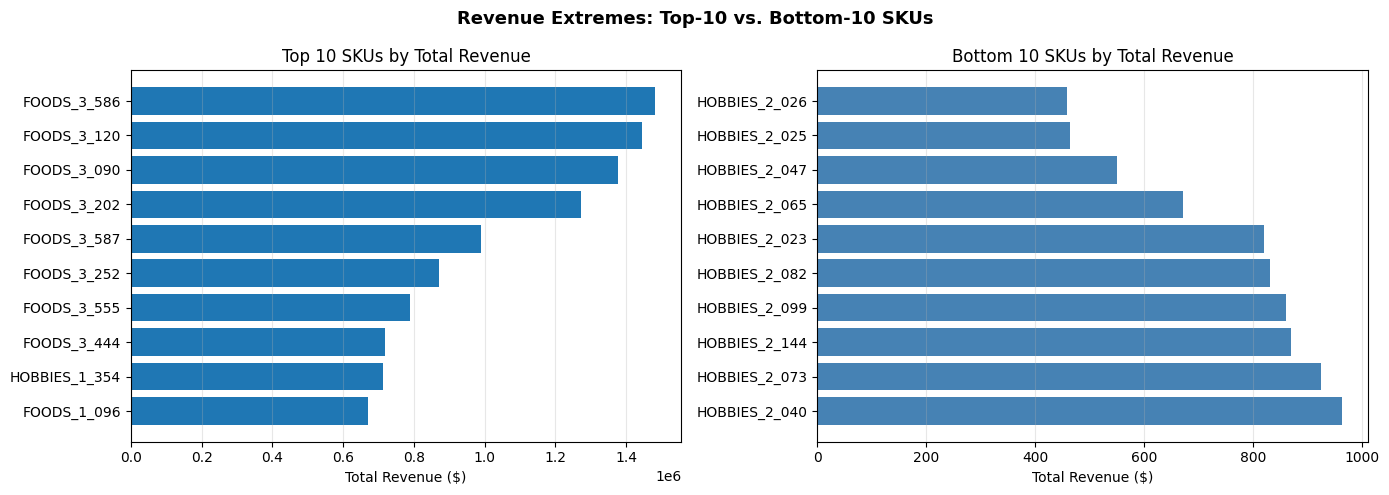

Top-10 revenue range : $670,077 – $1,482,295
Bottom-10 revenue range: $457.9300 – $962.7200


In [18]:
sku_revenue = (
    df.groupby("item_id", observed=True)["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"sales_amount": "total_revenue"})
)

top10 = sku_revenue.head(10)
bottom10 = sku_revenue.tail(10).sort_values("total_revenue", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10["item_id"].astype(str), top10["total_revenue"])
axes[0].set_title("Top 10 SKUs by Total Revenue")
axes[0].set_xlabel("Total Revenue ($)")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(bottom10["item_id"].astype(str), bottom10["total_revenue"], color="steelblue")
axes[1].set_title("Bottom 10 SKUs by Total Revenue")
axes[1].set_xlabel("Total Revenue ($)")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Revenue Extremes: Top-10 vs. Bottom-10 SKUs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Top-10 revenue range : ${top10['total_revenue'].min():,.0f} – ${top10['total_revenue'].max():,.0f}")
print(f"Bottom-10 revenue range: ${bottom10['total_revenue'].min():,.4f} – ${bottom10['total_revenue'].max():,.4f}")


**Business implication:** The gap between the top-10 and bottom-10 SKUs is enormous — often several orders of magnitude. Top revenue SKUs warrant the highest service levels and proactive safety-stock policies (A-tier). The bottom revenue SKUs contribute negligible sales dollars; stocking them to a 99 % service level would tie up capital with no meaningful business benefit — these are strong C-tier, possibly MTO or discontinuation candidates.

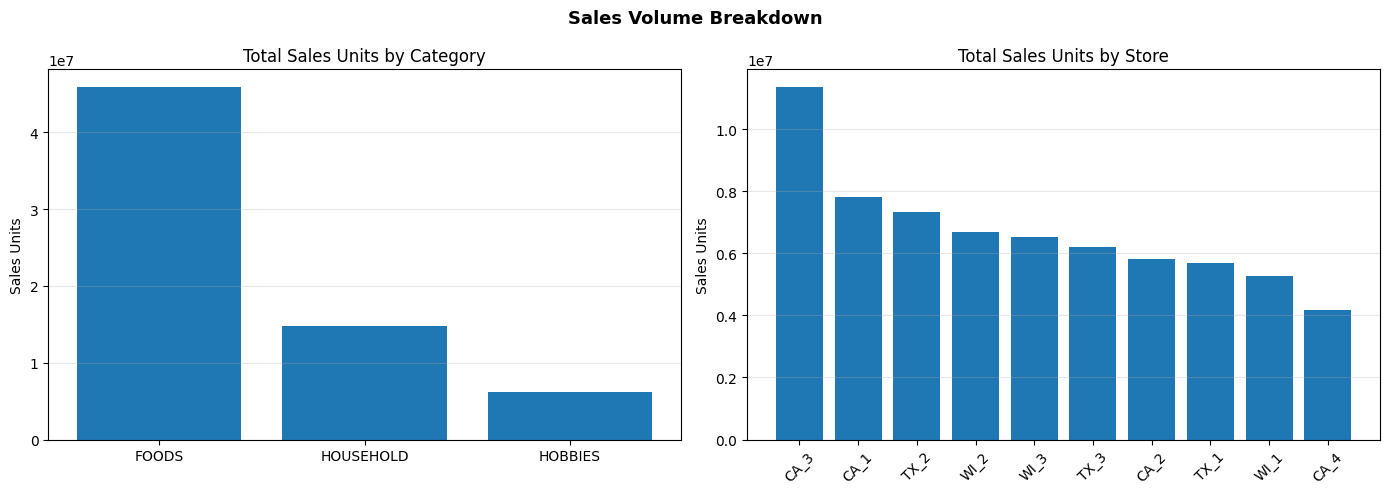

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_sales = df.groupby("cat_id", observed=True)["sales_units"].sum().sort_values(ascending=False)
axes[0].bar(cat_sales.index.astype(str), cat_sales.values)
axes[0].set_title("Total Sales Units by Category")
axes[0].set_ylabel("Sales Units")
axes[0].grid(axis="y", alpha=0.3)

store_sales = df.groupby("store_id", observed=True)["sales_units"].sum().sort_values(ascending=False)
axes[1].bar(store_sales.index.astype(str), store_sales.values)
axes[1].set_title("Total Sales Units by Store")
axes[1].set_ylabel("Sales Units")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Sales Volume Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Temporal Patterns

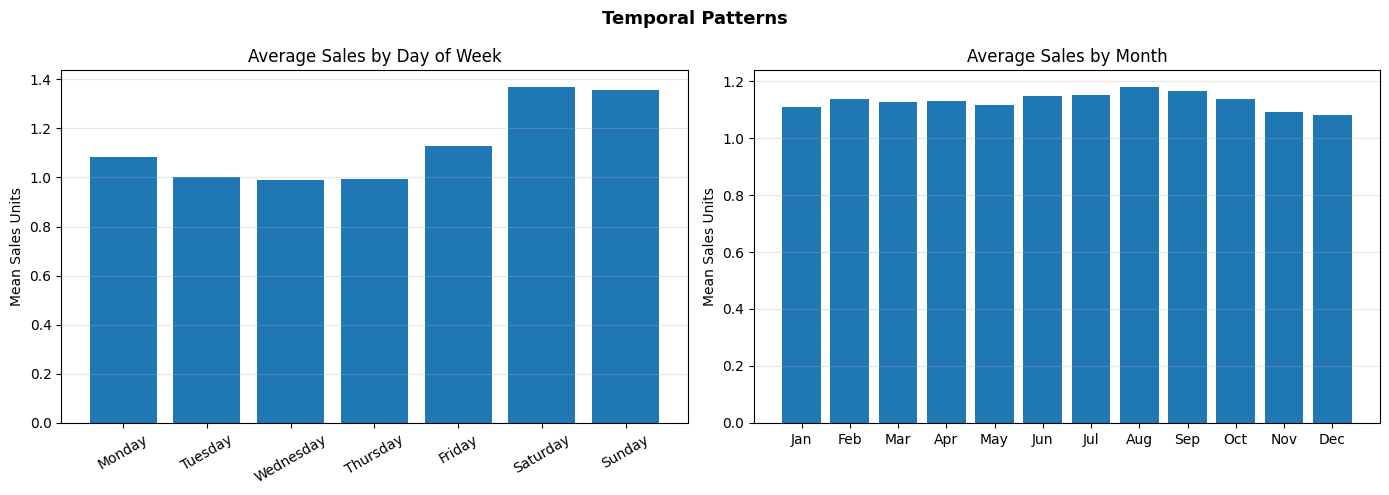

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = (
    df.assign(dow=df["date"].dt.day_name())
    .groupby("dow")["sales_units"]
    .mean()
    .reindex(dow_order)
)
axes[0].bar(dow_sales.index, dow_sales.values)
axes[0].set_title("Average Sales by Day of Week")
axes[0].set_ylabel("Mean Sales Units")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_sales = df.assign(month=df["date"].dt.month).groupby("month")["sales_units"].mean()
axes[1].bar(month_labels, month_sales.values)
axes[1].set_title("Average Sales by Month")
axes[1].set_ylabel("Mean Sales Units")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Temporal Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Business implication:** Sales exhibit strong, consistent weekly and annual seasonality. Weekend days show meaningfully higher average unit sales; December and the holiday season show the most pronounced annual uplift. A demand-forecasting model that ignores calendar features will systematically misforecast these predictable peaks and troughs — day-of-week, week-of-year, month, and holiday indicators are therefore essential features.

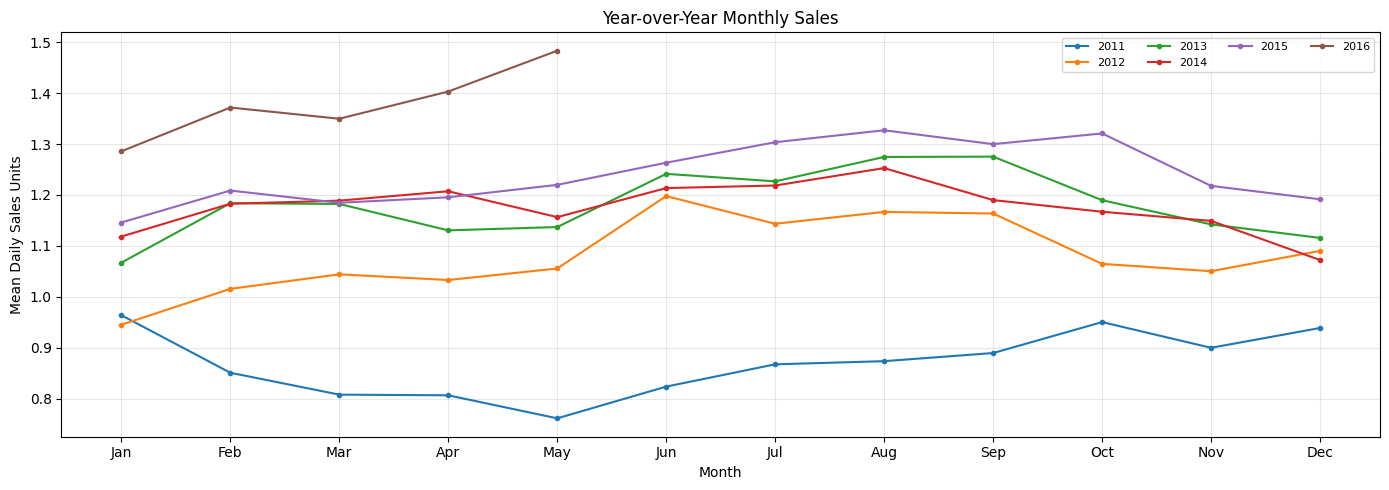

In [21]:
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
yoy = (
    df.assign(year=df["date"].dt.year, month=df["date"].dt.month)
    .groupby(["year", "month"])["sales_units"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for year in sorted(yoy["year"].unique()):
    sub = yoy[yoy["year"] == year]
    ax.plot(sub["month"], sub["sales_units"], marker="o", markersize=3,
            linewidth=1.5, label=str(year))
ax.set_title("Year-over-Year Monthly Sales")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Daily Sales Units")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend(ncol=4, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Sparsity

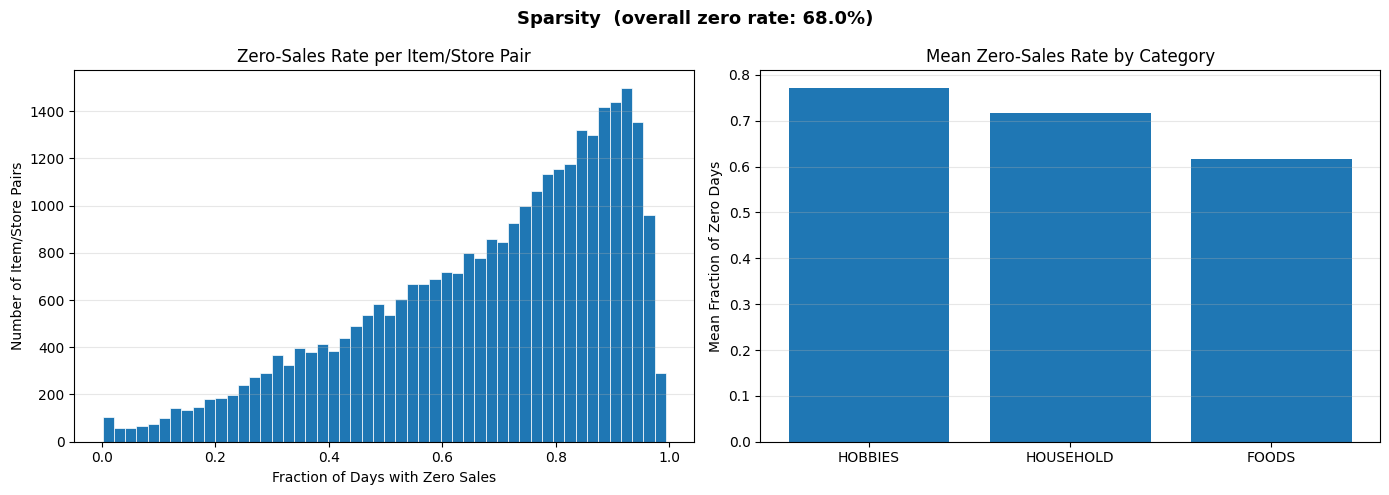

In [22]:
zero_rate = (
    df.assign(is_zero=(df["sales_units"] == 0))
    .groupby(["item_id", "store_id"], observed=True)["is_zero"]
    .mean()
    .reset_index(name="zero_rate")
)
zero_rate["cat_id"] = zero_rate["item_id"].str.split("_").str[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(zero_rate["zero_rate"], bins=50, edgecolor="white", linewidth=0.5)
axes[0].set_title("Zero-Sales Rate per Item/Store Pair")
axes[0].set_xlabel("Fraction of Days with Zero Sales")
axes[0].set_ylabel("Number of Item/Store Pairs")
axes[0].grid(axis="y", alpha=0.3)

cat_zero = zero_rate.groupby("cat_id")["zero_rate"].mean().sort_values(ascending=False)
axes[1].bar(cat_zero.index, cat_zero.values)
axes[1].set_title("Mean Zero-Sales Rate by Category")
axes[1].set_ylabel("Mean Fraction of Zero Days")
axes[1].grid(axis="y", alpha=0.3)

overall_zero = (df["sales_units"] == 0).mean()
plt.suptitle(f"Sparsity  (overall zero rate: {overall_zero:.1%})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Business implication — XYZ motivation:** The wide spread of zero-sales rates is a direct proxy for demand variability. Many item-store pairs record zero sales on the majority of days — these are highly intermittent, unpredictable series (high coefficient of variation). Others sell almost every day with relatively stable volume. This finding motivates **XYZ classification**: grouping SKUs by coefficient of variation (CV) of weekly demand lets us separate predictable series (X) from moderately variable (Y) and highly erratic ones (Z). CZ items — low revenue *and* erratic demand — are candidates for Make-to-Order or discontinuation.

### Events & SNAP

In [23]:
# Aggregate to daily/state level before joining calendar to keep memory low
date_event = calendar.set_index("date")[["event_name_1", "event_type_1", "snap_CA", "snap_TX", "snap_WI"]]
daily_by_state = (
    df.groupby(["date", "state_id"], observed=True)["sales_units"]
    .mean()
    .reset_index()
    .join(date_event, on="date")
)
daily_by_state["has_event"] = daily_by_state["event_name_1"].notna()

Avg daily sales on non-event days : 1.124
Avg daily sales on event days     : 1.073
Event lift                        : -4.5%


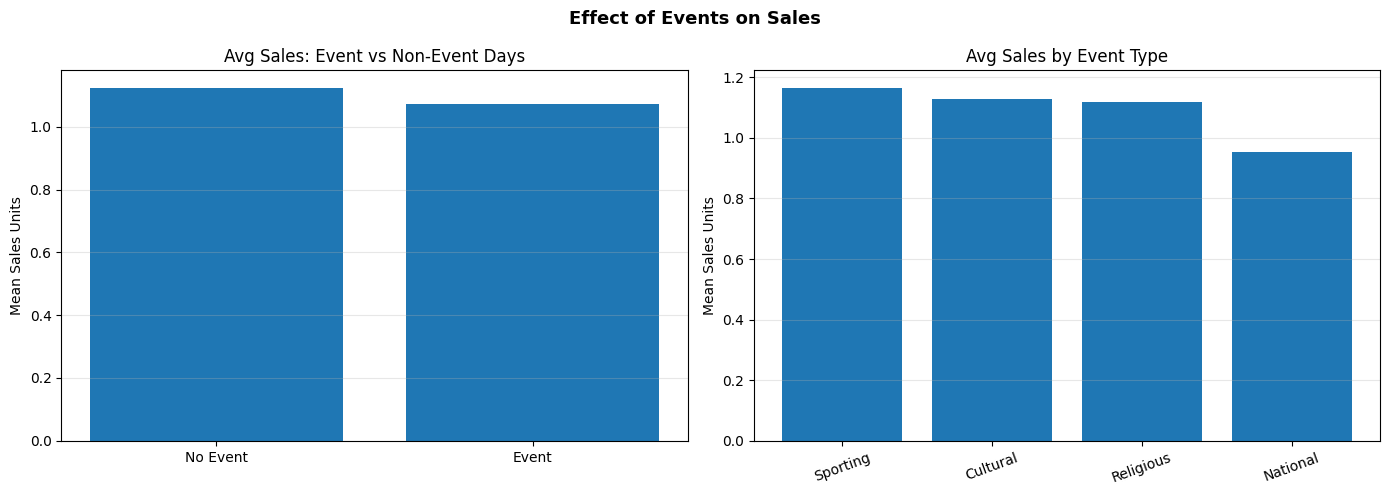

In [24]:
event_avg = daily_by_state.groupby("has_event")["sales_units"].mean()
print(f"Avg daily sales on non-event days : {event_avg[False]:.3f}")
print(f"Avg daily sales on event days     : {event_avg[True]:.3f}")
print(f"Event lift                        : {event_avg[True] / event_avg[False] - 1:+.1%}")

type_avg = (
    daily_by_state.dropna(subset=["event_type_1"])
    .groupby("event_type_1")["sales_units"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(["No Event", "Event"], event_avg.values)
axes[0].set_title("Avg Sales: Event vs Non-Event Days")
axes[0].set_ylabel("Mean Sales Units")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(type_avg.index, type_avg.values)
axes[1].set_title("Avg Sales by Event Type")
axes[1].set_ylabel("Mean Sales Units")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Effect of Events on Sales", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

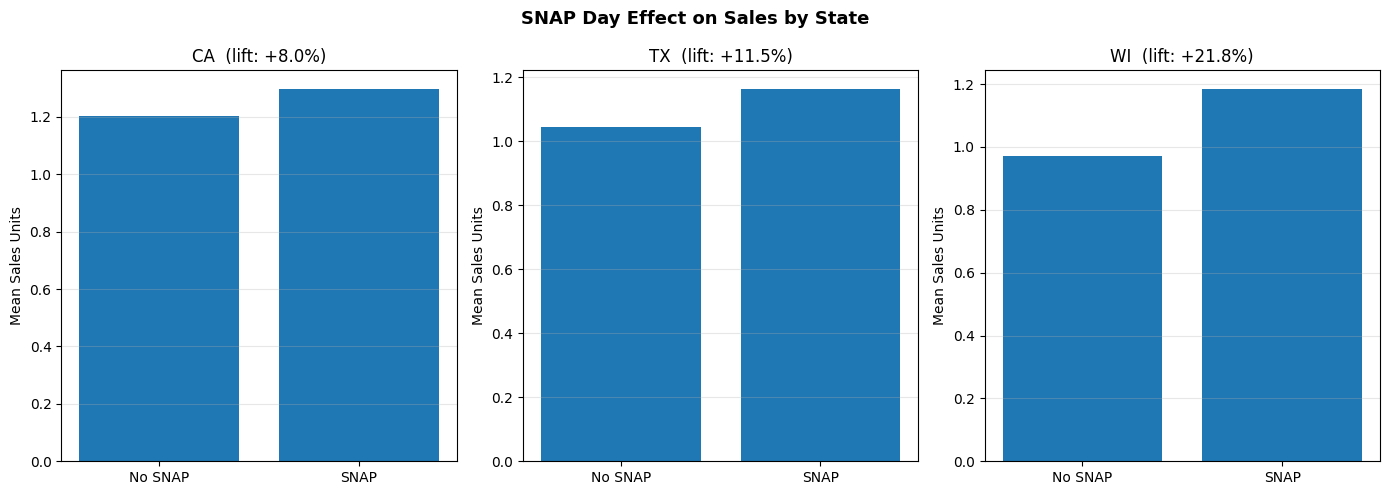

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (state, col) in zip(axes, [("CA", "snap_CA"), ("TX", "snap_TX"), ("WI", "snap_WI")]):
    state_data = daily_by_state[daily_by_state["state_id"] == state]
    snap_avg = state_data.groupby(col)["sales_units"].mean()
    lift = snap_avg[1] / snap_avg[0] - 1
    ax.bar(["No SNAP", "SNAP"], snap_avg.values)
    ax.set_title(f"{state}  (lift: {lift:+.1%})")
    ax.set_ylabel("Mean Sales Units")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("SNAP Day Effect on Sales by State", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Business implication:** SNAP (Supplemental Nutrition Assistance Program) disbursement days produce a measurable and consistent lift in sales — particularly in the FOODS category and in states with larger SNAP-eligible populations. Because SNAP days follow a published schedule, they are *predictable* demand spikes. Including per-state SNAP indicators as calendar features allows the model to anticipate these spikes rather than treat them as unexplained noise. For safety-stock sizing, SNAP lift means FOODS A-items may need temporarily higher buffer stock around disbursement dates.

### Demand Variability (Coefficient of Variation)

CV statistics across 30,490 item-store pairs:
  Min  CV : 0.15
  Mean CV : 1.26
  Median CV: 1.11
  Max  CV : 8.81

X items (CV < 0.5):                1,139 (3.7%)
Y items (0.5 ≤ CV < 1.0): 11,535 (37.8%)
Z items (CV ≥ 1.0):               17,816 (58.4%)


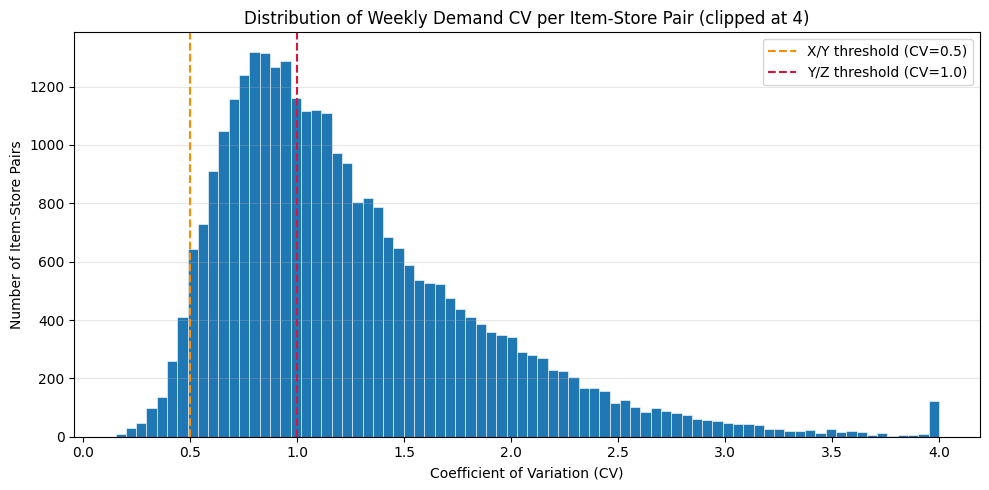

In [26]:
# Weekly demand per item-store pair
weekly_demand = (
    df.assign(week=df["date"].dt.to_period("W"))
    .groupby(["item_id", "store_id", "week"], observed=True)["sales_units"]
    .sum()
    .reset_index()
)

cv_df = (
    weekly_demand.groupby(["item_id", "store_id"], observed=True)["sales_units"]
    .agg(mean_demand="mean", std_demand="std")
    .reset_index()
)
# Avoid divide-by-zero for zero-mean series
cv_df["cv"] = cv_df["std_demand"] / cv_df["mean_demand"].replace(0, float("nan"))
cv_df = cv_df.dropna(subset=["cv"])

print(f"CV statistics across {len(cv_df):,} item-store pairs:")
print(f"  Min  CV : {cv_df['cv'].min():.2f}")
print(f"  Mean CV : {cv_df['cv'].mean():.2f}")
print(f"  Median CV: {cv_df['cv'].median():.2f}")
print(f"  Max  CV : {cv_df['cv'].max():.2f}")
print()

# XYZ thresholds
x_thresh, y_thresh = 0.5, 1.0
x_count = (cv_df["cv"] <  x_thresh).sum()
y_count = ((cv_df["cv"] >= x_thresh) & (cv_df["cv"] < y_thresh)).sum()
z_count = (cv_df["cv"] >= y_thresh).sum()
total   = len(cv_df)
print(f"X items (CV < {x_thresh}):                {x_count:,} ({x_count/total:.1%})")
print(f"Y items ({x_thresh} ≤ CV < {y_thresh}): {y_count:,} ({y_count/total:.1%})")
print(f"Z items (CV ≥ {y_thresh}):               {z_count:,} ({z_count/total:.1%})")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(cv_df["cv"].clip(upper=4), bins=80, edgecolor="white", linewidth=0.4)
ax.axvline(x_thresh, color="darkorange", linestyle="--", linewidth=1.5, label=f"X/Y threshold (CV={x_thresh})")
ax.axvline(y_thresh, color="crimson",    linestyle="--", linewidth=1.5, label=f"Y/Z threshold (CV={y_thresh})")
ax.set_title("Distribution of Weekly Demand CV per Item-Store Pair (clipped at 4)")
ax.set_xlabel("Coefficient of Variation (CV)")
ax.set_ylabel("Number of Item-Store Pairs")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Business implication — XYZ classification:** CV ranges dramatically across the catalogue — from near-zero (highly predictable series) to well above 1.0 (highly erratic series). The majority of item-store pairs fall in the Y or Z zones, confirming that one-size-fits-all safety-stock formulas would be severely mis-calibrated. XYZ segmentation lets us:

* **X-items (CV < 0.5):** Apply standard statistical safety-stock; forecast error is modest.
* **Y-items (0.5 ≤ CV < 1.0):** Require higher safety-stock multiples; moderate uncertainty.
* **Z-items (CV ≥ 1.0):** Demand is so erratic that conventional safety-stock may be prohibitively expensive; MTO or discontinuation policies may be warranted, especially for low-revenue CZ items.

This CV analysis, combined with the Pareto revenue analysis above, forms the empirical foundation for the 9-cell ABC-XYZ matrix that drives all downstream inventory policy recommendations.